# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score)

import warnings
warnings.filterwarnings("ignore")

Required libraries were imported for data analysis, visualization & machine learning.

# Load Dataset

In [2]:
df = pd.read_csv("INDUSTRY.csv")

In [3]:
df.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,13-10-2025,Asia
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,01-12-2025,Europe
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,04-05-2025,North America
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,01-02-2026,North America
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,29-06-2025,Asia


In [4]:
df.tail()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
14995,14996,FinTrust_14996,Finance,USA,2814,369.06,25.59,2011,52295,1.6,25-08-2024,North America
14996,14997,TechNova_14997,Technology,India,3977,758.47,32.68,2019,4118,0.3,30-04-2024,Asia
14997,14998,RetailHub_14998,Retail,Germany,454,859.89,15.36,1999,54468,0.1,05-04-2024,Europe
14998,14999,BuildWorks_14999,Manufacturing,Canada,2787,111.92,41.82,2019,74866,1.9,30-12-2024,North America
14999,15000,MediCorp_15000,Healthcare,USA,1473,879.67,29.31,2003,12998,2.0,14-03-2024,North America


In [5]:
df.sample(5)

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region
8988,8989,BuildWorks_8989,Manufacturing,India,2565,763.70,39.37,2013,73926,1.9,31-01-2026,Asia
4982,4983,RetailHub_4983,Retail,Canada,2351,762.30,28.22,2005,33231,1.1,07-01-2025,North America
13531,13532,TechNova_13532,Technology,USA,3807,470.62,23.09,2016,69847,1.0,22-08-2024,North America
8057,8058,RetailHub_8058,Retail,Germany,869,937.77,18.01,2006,51847,2.6,26-12-2025,Europe
1029,1030,MediCorp_1030,Healthcare,Germany,3456,410.73,15.01,2004,53735,4.3,24-03-2024,Europe


# Dataset Shape

In [6]:
df.shape

(15000, 12)

# Dataset Information

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      15000 non-null  int64  
 1   company_name            15000 non-null  object 
 2   industry                15000 non-null  object 
 3   country                 15000 non-null  object 
 4   employee_count          15000 non-null  int64  
 5   annual_revenue_million  15000 non-null  float64
 6   profit_margin_percent   15000 non-null  float64
 7   founded_year            15000 non-null  int64  
 8   customer_count          15000 non-null  int64  
 9   market_rating           15000 non-null  float64
 10  created_date            15000 non-null  object 
 11  region                  15000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 1.4+ MB


# Check Missing Values

In [8]:
df.isnull().sum()

id                        0
company_name              0
industry                  0
country                   0
employee_count            0
annual_revenue_million    0
profit_margin_percent     0
founded_year              0
customer_count            0
market_rating             0
created_date              0
region                    0
dtype: int64

No missing values found in this dataset

# Check Duplicate Values

In [9]:
df.duplicated().sum()

np.int64(0)

No duplicate values found in this dataset.

# Feature Engineering

In [10]:
df["company_age"] = 2026 - df["founded_year"]

In [11]:
df[["founded_year","company_age"]].head()

,founded_year,company_age
0,2010,16
1,2010,16
2,1996,30
3,1993,33
4,1996,30


Company age was calculated using the founded year.

# Date Conversion

In [12]:
df["created_date"] = pd.to_datetime(df["created_date"], dayfirst=True)

In [13]:
df["created_year"] = df["created_date"].dt.year
df["created_month"] = df["created_date"].dt.month

In [14]:
df.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region,company_age,created_year,created_month
0,1,FinTrust_1,Finance,India,535,539.38,40.42,2010,81191,0.7,2025-10-13,Asia,16,2025,10
1,2,TechNova_2,Technology,Germany,3806,852.42,39.55,2010,92162,3.4,2025-12-01,Europe,16,2025,12
2,3,RetailHub_3,Retail,Canada,2779,257.11,23.68,1996,27532,2.9,2025-05-04,North America,30,2025,5
3,4,BuildWorks_4,Manufacturing,USA,835,309.14,31.31,1993,90815,0.9,2026-02-01,North America,33,2026,2
4,5,MediCorp_5,Healthcare,India,4490,988.68,43.65,1996,850,0.5,2025-06-29,Asia,30,2025,6


Additional date based features add for better analysis.

# Check Numerical Columns

In [15]:
num_cols = df.select_dtypes(include = np.number).columns

num_cols

Index(['id', 'employee_count', 'annual_revenue_million',
       'profit_margin_percent', 'founded_year', 'customer_count',
       'market_rating', 'company_age', 'created_year', 'created_month'],
      dtype='object')

Numerical variables identified for analysis.

# Check Categorical Columns

In [16]:
cat_cols = df.select_dtypes(include = "object").columns

cat_cols

Index(['company_name', 'industry', 'country', 'region'], dtype='object')

Categorical variables identified for analysis.

# Check Mean, Median & Standard Deviation

In [17]:
stats = pd.DataFrame({"Mean": df[num_cols].mean(),"Median": df[num_cols].median(),"Standard Deviation": df[num_cols].std()}).round(2)

print("Descriptive Statistics:")
print(stats)

Descriptive Statistics:
                            Mean    Median  Standard Deviation
id                       7500.50   7500.50             4330.27
employee_count           2606.86   2587.00             1430.56
annual_revenue_million    549.73    543.92              288.24
profit_margin_percent      25.01     24.91               11.53
founded_year             2004.37   2004.00                8.61
customer_count          50449.25  50726.50            28744.64
market_rating               2.51      2.50                1.45
company_age                21.63     22.00                8.61
created_year             2024.61   2025.00                0.62
created_month               6.13      6.00                3.58


The descriptive statistics provide valuable insights into the overall characteristics of the dataset.

mean values indicate the average performance of companies.

median values represent the central tendency of the data.

standard deviation measures the variability present among different business indicators.

# Industry Distribution

In [18]:
industry_count = df["industry"].value_counts()

industry_count

industry
Finance          3000
Technology       3000
Retail           3000
Manufacturing    3000
Healthcare       3000
Name: count, dtype: int64

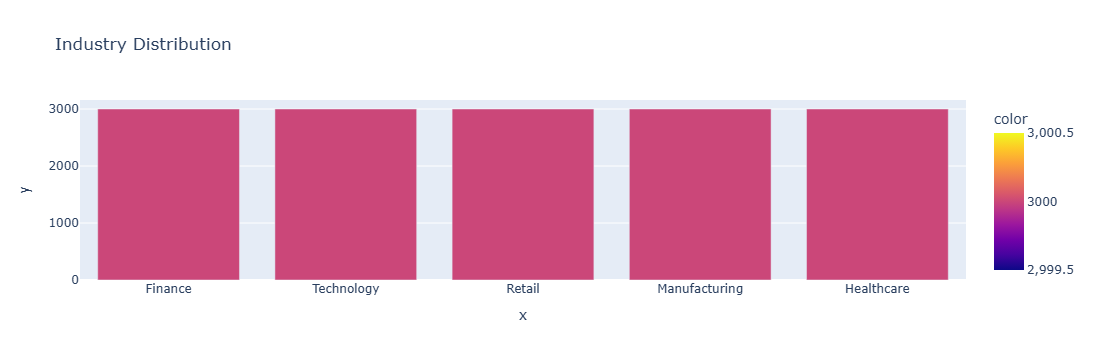

In [19]:
fig = px.bar(x = industry_count.index, y = industry_count.values, color = industry_count.values, title = "Industry Distribution")

fig.show()

The dataset contains companies from multiple industries creating balancing environment for analysis.

# Country Distribution

In [20]:
country_count = df["country"].value_counts()

country_count

country
India      3750
Germany    3750
Canada     3750
USA        3750
Name: count, dtype: int64

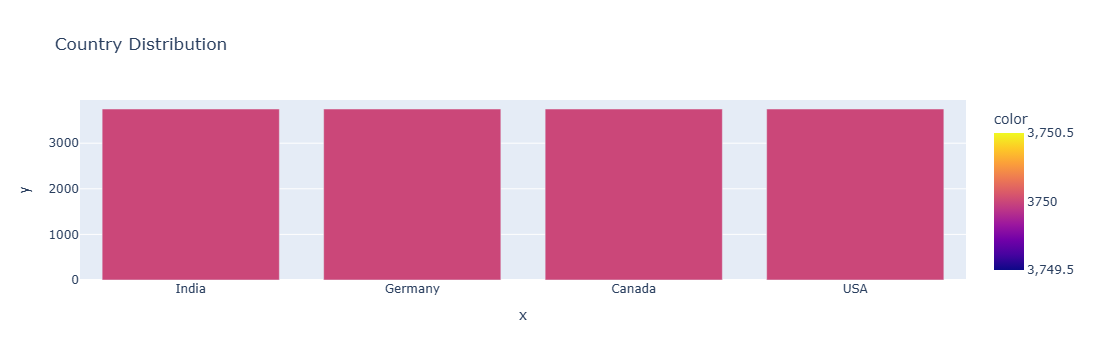

In [21]:
fig = px.bar(x = country_count.index, y = country_count.values, color = country_count.values, title = "Country Distribution")

fig.show()

Companies are distributed across different countries provide geographical diversity within the dataset.

# Region Distribution

In [22]:
region_count = df["region"].value_counts()

region_count

region
North America    7500
Asia             3750
Europe           3750
Name: count, dtype: int64

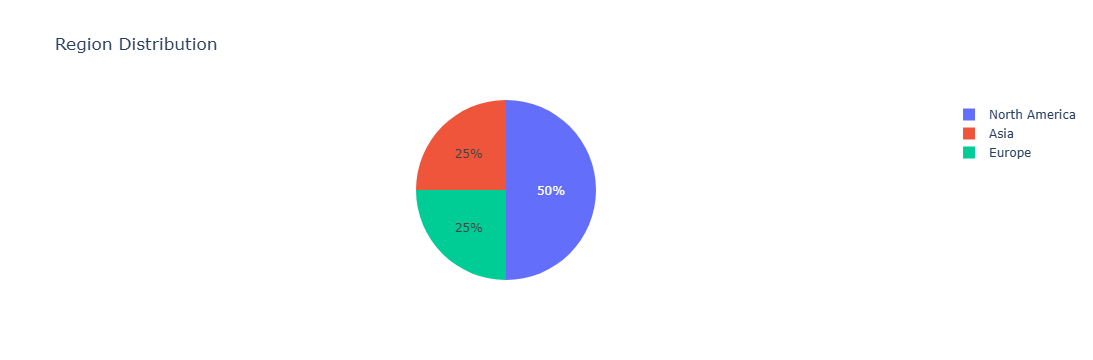

In [23]:
fig = px.pie(values = region_count.values, names = region_count.index, title = "Region Distribution")

fig.show()

Different regions contribute to the overall business distribution represented in the dataset.

# Revenue Distribution

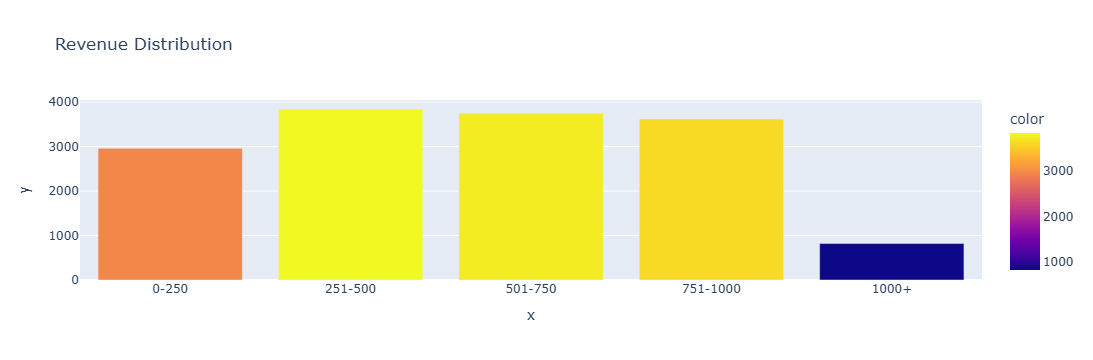

In [24]:
bins = [0, 250, 500, 750, 1000, 1100]

labels = ["0-250", "251-500", "501-750", "751-1000", "1000+"]

df["revenue_group"] = pd.cut(df["annual_revenue_million"], bins=bins, labels=labels)

group_count = (df["revenue_group"].value_counts().sort_index())

fig = px.bar(x=group_count.index, y=group_count.values, title="Revenue Distribution", color=group_count.values)

fig.show()

Most companies earn medium revenue.

only a few companies have very high revenue.

# Univariate Analysis

### Employee Count Distribution

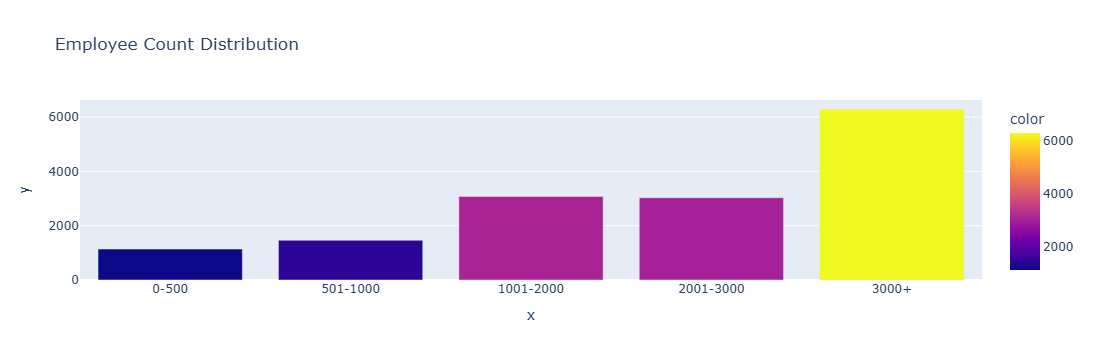

In [25]:
bins = [0, 500, 1000, 2000, 3000, 5100]

labels = ["0-500", "501-1000", "1001-2000", "2001-3000", "3000+"]

df["employee_group"] = pd.cut(df["employee_count"], bins=bins, labels=labels)

group_count = (df["employee_group"].value_counts().sort_index())

fig = px.bar(x=group_count.index, y=group_count.values, title="Employee Count Distribution", color=group_count.values)

fig.show()

Most companies have a minium number of employees.

Only a few companies have more than 3000 employees.

### Customer Count Distribution

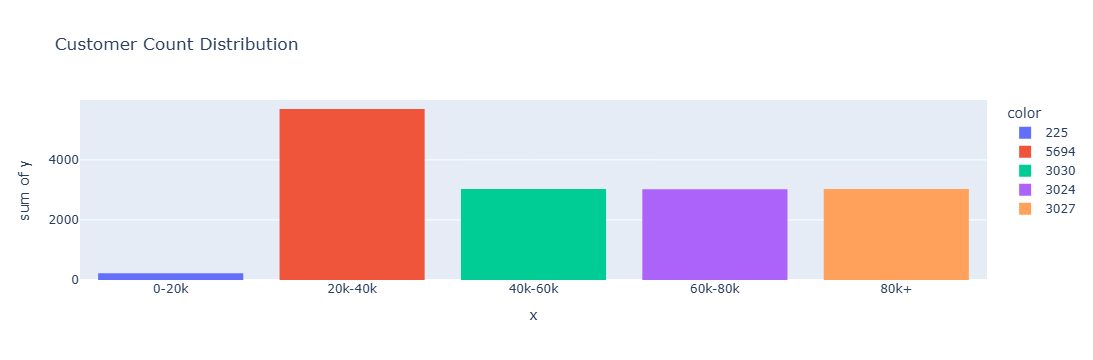

In [26]:
bins = [0, 2000, 40000, 60000, 80000, 101000]

labels = ["0-20k", "20k-40k", "40k-60k", "60k-80k", "80k+"]

df["customer_group"] = pd.cut(df["customer_count"], bins=bins, labels=labels)

group_count = (df["customer_group"].value_counts().sort_index())

fig = px.histogram(x=group_count.index, y=group_count.values, title="Customer Count Distribution", color=group_count.values)

fig.show()

Most companies fall into the middle customer count categories.

Some companies have a very large customer base.

### Profit Margin Distribution

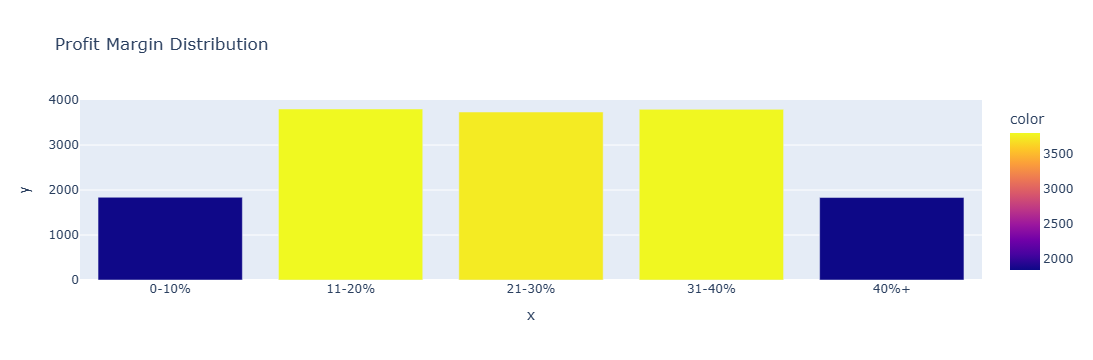

In [27]:
bins = [0, 10, 20, 30, 40, 50]

labels =["0-10%", "11-20%", "21-30%", "31-40%", "40%+"]

df["profit_group"] = pd.cut(df["profit_margin_percent"], bins=bins, labels=labels)

group_count = (df["profit_group"].value_counts().sort_index())

fig = px.bar(x=group_count.index, y=group_count.values, title="Profit Margin Distribution", color=group_count.values)

fig.show()

Most companies fall into the middle profit margin categories.

Only few companies have very low or very high profit margins.

### Market Rating Distribution

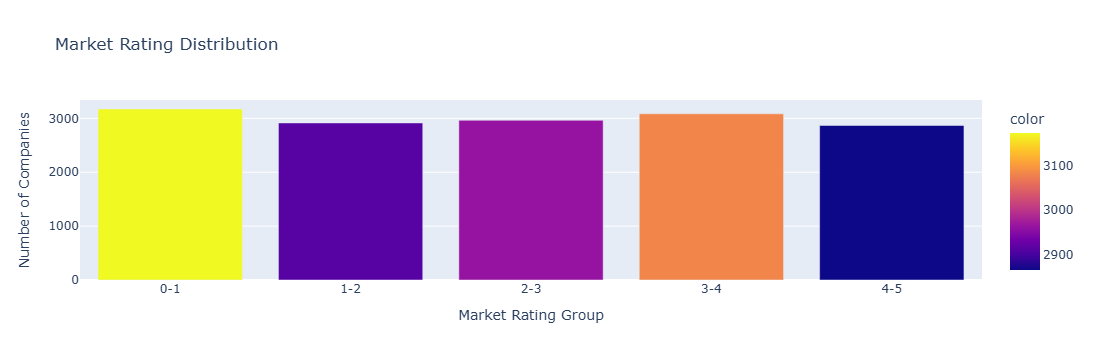

In [28]:
bins = [0, 1, 2, 3, 4, 5]

labels = ["0-1", "1-2", "2-3", "3-4", "4-5"]

df["rating_group"] = pd.cut(df["market_rating"], bins=bins, labels=labels, include_lowest=True)

rating_count = (df["rating_group"].value_counts().sort_index())

rating_count

fig = px.bar(x = rating_count.index, y = rating_count.values, color = rating_count.values, title = "Market Rating Distribution", labels = {"x": "Market Rating Group", "y": "Number of Companies"})

fig.show()

### Region Distribution

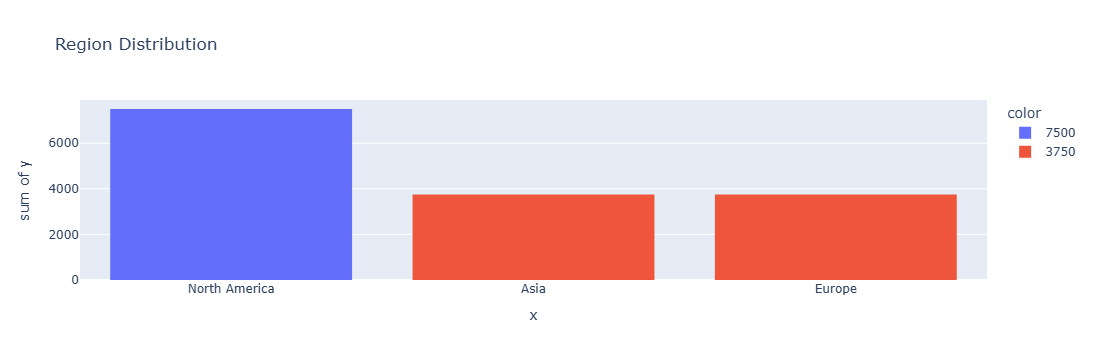

In [29]:
region_count = (df["region"].value_counts())

fig = px.histogram(x=region_count.index, y=region_count.values, title="Region Distribution", color=region_count.values)

fig.show()

Companies are spread across different regions.

Some regions contain more companies than others.

### Skewness & Kurtosis

In [30]:
stats_df = pd.DataFrame({"Column": ["employee_count", "annual_revenue_million", "profit_margin_percent", "customer_count", "market_rating"],
                         
                         "skewness": [df["employee_count"].skew(), df["annual_revenue_million"].skew(), df["profit_margin_percent"].skew(),
                                      df["customer_count"].skew(), df["market_rating"].skew()],

                         "Kurtosis": [df["employee_count"].kurt(), df["annual_revenue_million"].kurt(), df["profit_margin_percent"].kurt(),
                                      df["customer_count"].kurt(), df["market_rating"].kurt()]})
stats_df

,Column,skewness,Kurtosis
0,employee_count,0.002354,-1.187695
1,annual_revenue_million,0.027341,-1.187059
2,profit_margin_percent,0.002560,-1.202566
3,customer_count,-0.004866,-1.194714
4,market_rating,-0.020033,-1.205761


The skewness values are close to zero.

This means the numerical data is almost balanced.

The kurtosis values are negative which means there are few extreme values in the dataset.

# Outlier Detection

### Employee Count Outlier Detection

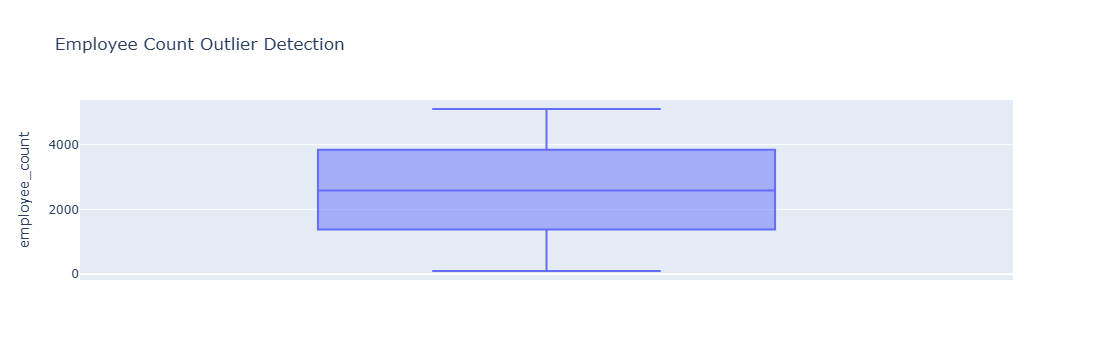

In [31]:
fig = px.box(df, y="employee_count", title="Employee Count Outlier Detection")

fig.show()

### Annual Revenue Outlier Detection

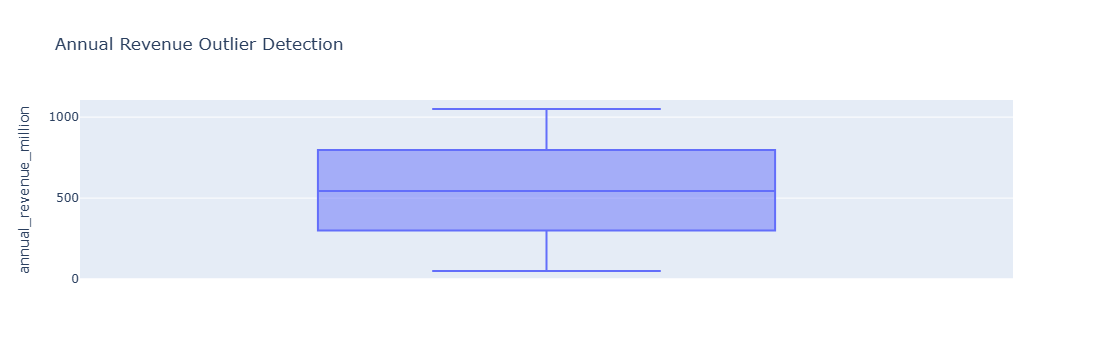

In [32]:
fig = px.box(df, y="annual_revenue_million", title="Annual Revenue Outlier Detection")

fig.show()

### Profit Margin Outlier Detection

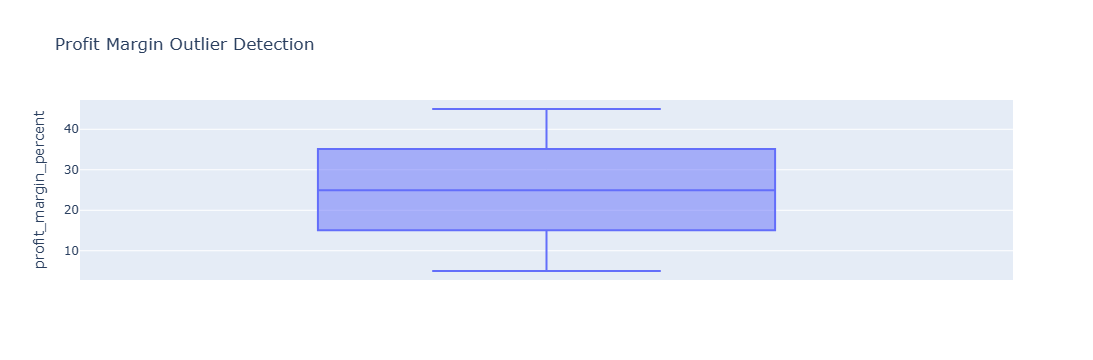

In [33]:
fig = px.box(df, y="profit_margin_percent", title="Profit Margin Outlier Detection")

fig.show()

### Customer Count Outlier Detection

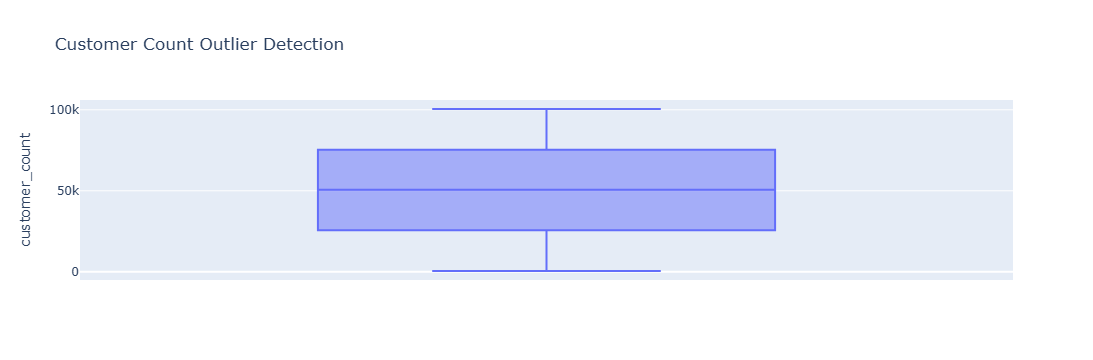

In [34]:
fig = px.box(df, y="customer_count", title="Customer Count Outlier Detection")

fig.show()

Box plots were used to check for outliers in numerical features.

No major outliers patterns were observed.

# IQR Method

In [35]:
Q1 = df["annual_revenue_million"].quantile(0.25)

Q3 = df["annual_revenue_million"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)

upper_bound = Q3 + (1.5 * IQR)

revenue_outliers = df[
    (df["annual_revenue_million"] < lower_bound) |
    (df["annual_revenue_million"] > upper_bound)
]

print("Number of Revenue Outliers:", len(revenue_outliers))

Number of Revenue Outliers: 0


# Bivariate Analysis

### Average Revenue By Industry

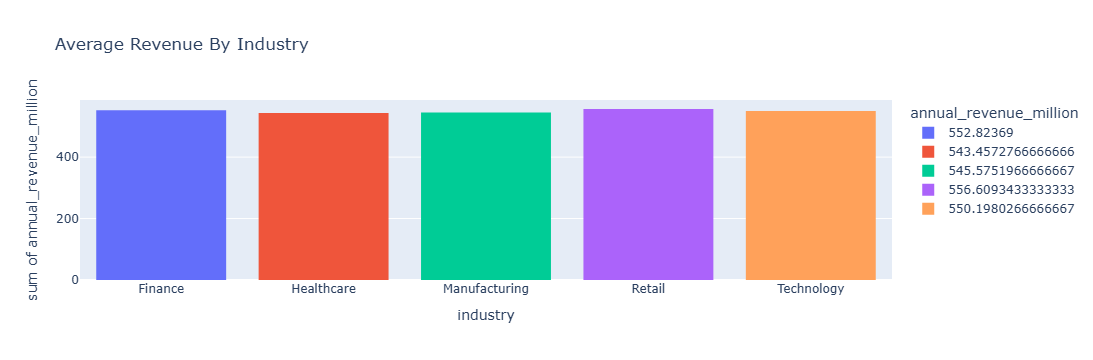

In [36]:
industry_revenue = (df.groupby("industry")["annual_revenue_million"].mean().reset_index())

fig = px.histogram(industry_revenue, x="industry", y="annual_revenue_million", color="annual_revenue_million", title="Average Revenue By Industry")

fig.show()

Different industries may generate different average revenue levels.

### Average Revenue By Region

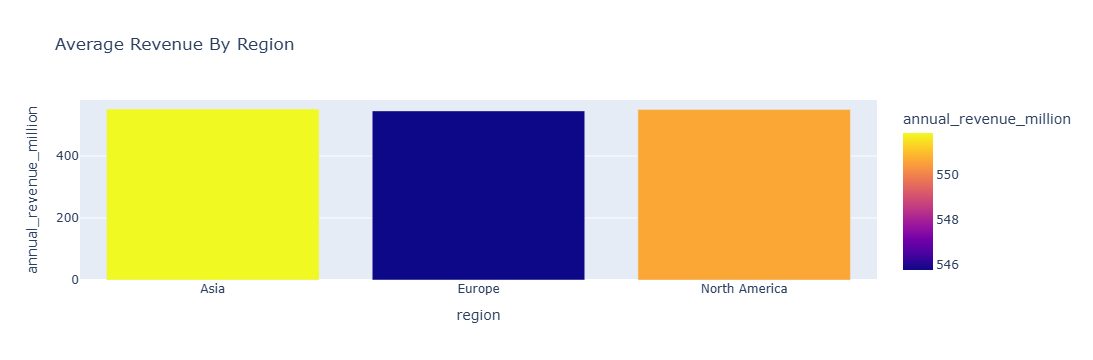

In [37]:
region_revenue = (df.groupby("region")["annual_revenue_million"].mean().reset_index())

fig = px.bar(region_revenue, x="region", y="annual_revenue_million", color="annual_revenue_million", title="Average Revenue By Region")

fig.show()

Some regions may have higher average revenue than others.

### Average Profit Margin by Industry

In [38]:
industry_profit = (df.groupby("industry")["profit_margin_percent"].mean().reset_index())

industry_profit

,industry,profit_margin_percent
0,Finance,25.303310
1,Healthcare,24.878077
2,Manufacturing,24.762147
3,Retail,25.085197
4,Technology,25.031367


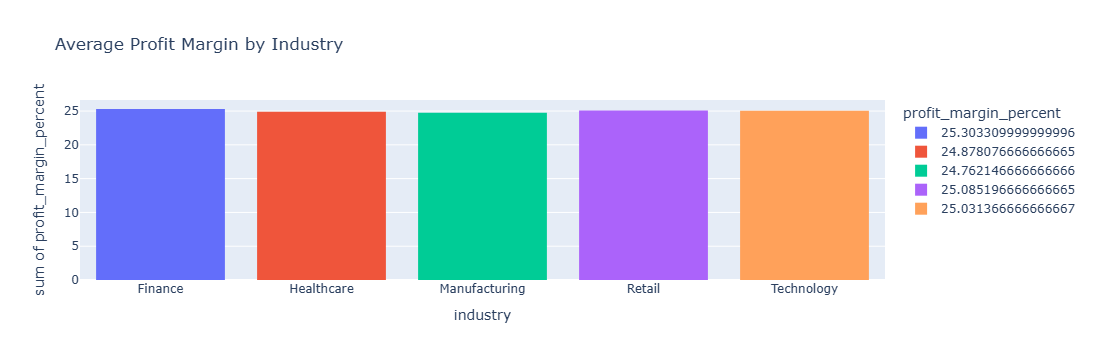

In [39]:
fig = px.histogram(
    industry_profit,
    x="industry",
    y="profit_margin_percent",
    color="profit_margin_percent",
    title="Average Profit Margin by Industry"
)

fig.show()

# Correlation Heatmap

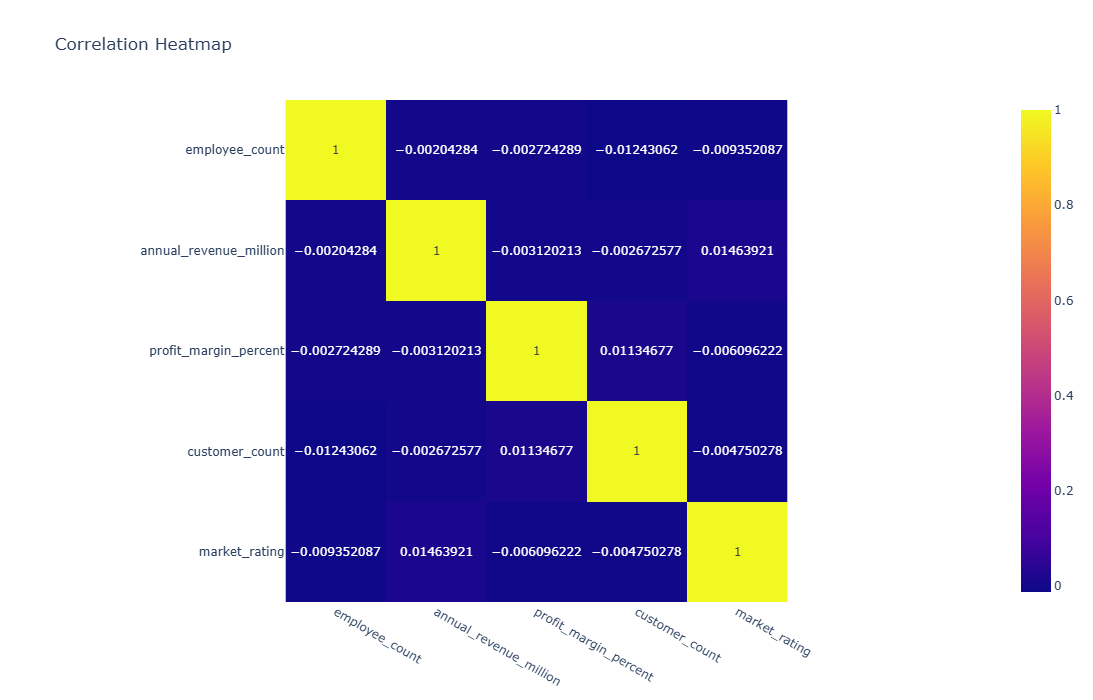

In [40]:
corr_matrix = df[["employee_count", "annual_revenue_million", "profit_margin_percent", "customer_count", "market_rating"]].corr()

fig = px.imshow(corr_matrix, text_auto=True, title="Correlation Heatmap")

fig.update_layout(width=900, height=700)

fig.show()

# Multivariate Analysis

### Revenue By Industry & Region

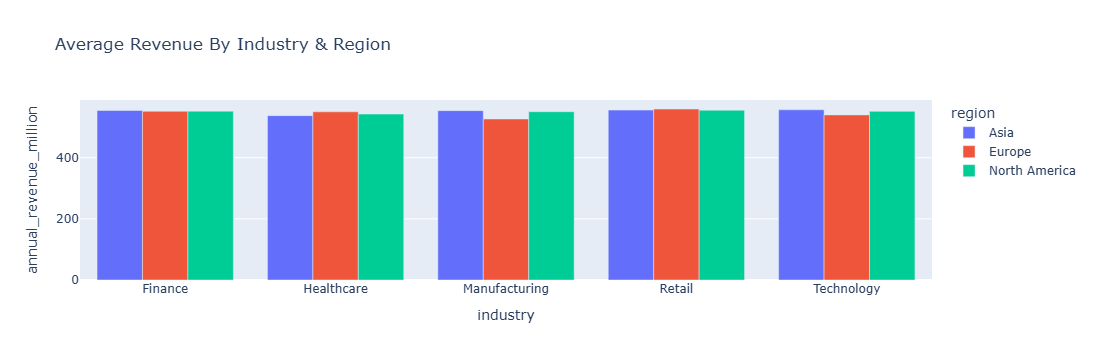

In [41]:
multi_df = (df.groupby(["industry", "region"])["annual_revenue_million"].mean().reset_index())

fig = px.bar(multi_df, x="industry", y="annual_revenue_million", color="region", barmode="group", title="Average Revenue By Industry & Region")

fig.show()

Some industry region are used to compare avarage annual revenue.

this chart helps identify revenue difference across industries & regions.

### Customer Count by Country and Industry

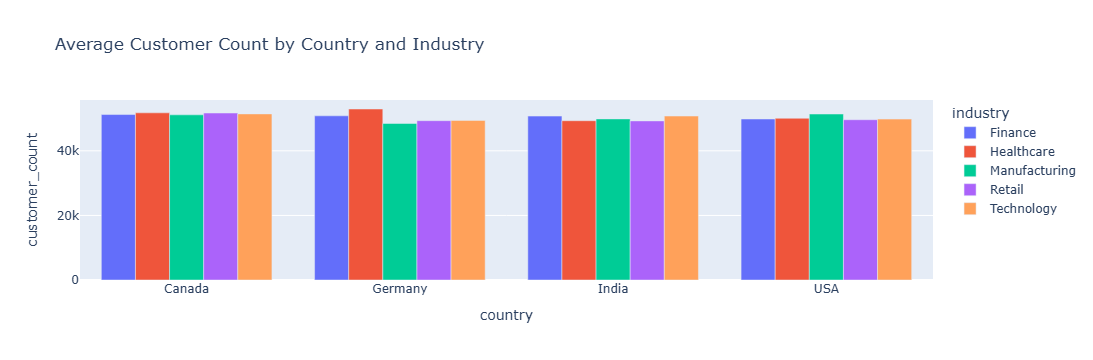

In [42]:
customer_analysis = (df.groupby(["country", "industry"])["customer_count"].mean().reset_index())

customer_analysis.head()

fig = px.bar(customer_analysis, x = "country", y = "customer_count", color = "industry", barmode = "group", title = "Average Customer Count by Country and Industry")

fig.show()

# Supervised Machine Learning

In [43]:
df_ml = df.copy()

A separate copy of the dataset was created to perform machine learning tasks without affecting the original dataset.

# Label Encoding

In [44]:
le = LabelEncoder()

categorical_cols = ["industry", "country", "region"]

for col in categorical_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,id,company_name,industry,country,employee_count,annual_revenue_million,profit_margin_percent,founded_year,customer_count,market_rating,created_date,region,company_age,created_year,created_month,revenue_group,employee_group,customer_group,profit_group,rating_group
0,1,FinTrust_1,0,2,535,539.38,40.42,2010,81191,0.7,2025-10-13,0,16,2025,10,501-750,501-1000,80k+,40%+,0-1
1,2,TechNova_2,4,1,3806,852.42,39.55,2010,92162,3.4,2025-12-01,1,16,2025,12,751-1000,3000+,80k+,31-40%,3-4
2,3,RetailHub_3,3,0,2779,257.11,23.68,1996,27532,2.9,2025-05-04,2,30,2025,5,251-500,2001-3000,20k-40k,21-30%,2-3
3,4,BuildWorks_4,2,3,835,309.14,31.31,1993,90815,0.9,2026-02-01,2,33,2026,2,251-500,501-1000,80k+,31-40%,0-1
4,5,MediCorp_5,1,2,4490,988.68,43.65,1996,850,0.5,2025-06-29,0,30,2025,6,751-1000,3000+,0-20k,40%+,0-1


Categorical variables were converted into numerical form to make them suitable for machine learning algorithms.

# Select Features and Target Variable

In [45]:
X = df_ml[["industry", "country", "employee_count", "profit_margin_percent", "customer_count", "market_rating", "region", "company_age", "created_year", "created_month"]]

y = df_ml["annual_revenue_million"]

Relevant business indicators were selected as independent variables, while annual revenue was chosen as the target variable for prediction.

# Train, Test & Split

In [46]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

The dataset was divided into training and testing sets to evaluate the model's performance on unseen data.

# Display Dataset Shapes

In [47]:
print("Training Features Shape :", X_train.shape)
print("Testing Features Shape  :", X_test.shape)

print()

print("Training Target Shape   :", y_train.shape)
print("Testing Target Shape    :", y_test.shape)

Training Features Shape : (12000, 10)
Testing Features Shape  : (3000, 10)

Training Target Shape   : (12000,)
Testing Target Shape    : (3000,)


# Train Linear Regression Model

In [48]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Linear Regression was used as a supervised learning algorithm to establish relationships between business variables and annual revenue.

# Make Predictions

In [49]:
y_pred = model.predict(X_test)

The trained model generated revenue predictions for the testing dataset.

# Compare Actual and Predicted Values

In [50]:
results = pd.DataFrame({"Actual Revenue": y_test, "Predicted Revenue": y_pred})

results.head(10)

,Actual Revenue,Predicted Revenue
11499,129.01,551.005033
6475,759.85,541.960987
13167,296.36,553.899847
862,913.22,539.492509
5970,411.28,548.188457
6706,744.67,530.137276
3017,511.28,547.589709
3781,264.00,555.516254
3898,889.57,545.252419
2250,98.89,545.926764


Comparing actual and predicted values helps assess the effectiveness of the predictive model.

# Evaluation Metrics

In [51]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)


evaluation = pd.DataFrame({"Metric": ["MAE", "MSE", "RMSE", "R² Score"], "Value": [round(mae, 2), round(mse, 2), round(rmse, 2), round(r2, 4)]})

print("Model Evaluation Metrics:")
print(evaluation)

Model Evaluation Metrics:
     Metric       Value
0       MAE    248.3300
1       MSE  82469.2700
2      RMSE    287.1700
3  R² Score     -0.0001


Model evaluation metrics were used to assess the predictive performance of the Linear Regression model.

MAE measures the average prediction error.

MSE gives higher importance to larger errors.

RMSE represents the prediction error in the original revenue units.

R² Score indicates how well the model explains the variation in annual revenue.

# Actual vs Predicted Revenue Comparison

In [52]:
results = pd.DataFrame({"Actual Revenue": y_test, "Predicted Revenue": y_pred})

results = results.reset_index(drop=True)

results.head(10)

,Actual Revenue,Predicted Revenue
0,129.01,551.005033
1,759.85,541.960987
2,296.36,553.899847
3,913.22,539.492509
4,411.28,548.188457
5,744.67,530.137276
6,511.28,547.589709
7,264.00,555.516254
8,889.57,545.252419
9,98.89,545.926764


The comparison between actual and predicted revenue values helps evaluate how closely the model's predictions align with real business outcomes.

Smaller differences indicate better predictive performance.

# Actual vs Predicted Revenue Visualization

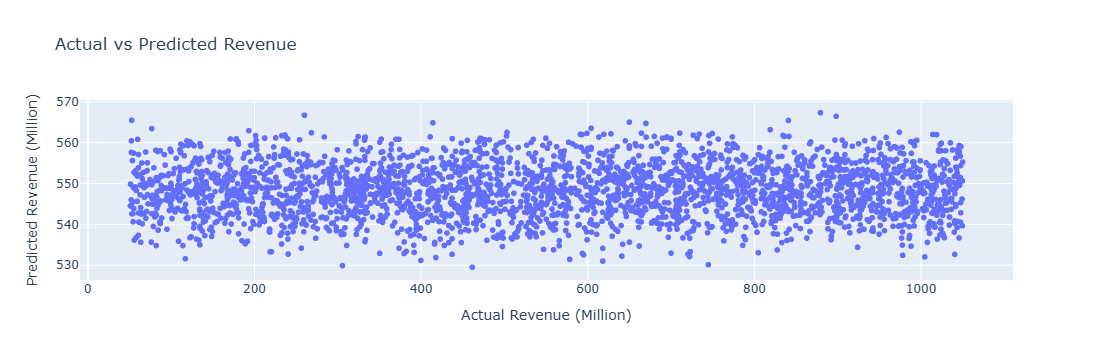

In [53]:
fig = px.scatter(results, x = "Actual Revenue", y = "Predicted Revenue", title = "Actual vs Predicted Revenue", labels = {"Actual Revenue": "Actual Revenue (Million)", "Predicted Revenue": "Predicted Revenue (Million)"})

fig.show()

The scatter plot illustrates the relationship between actual and predicted values.

Points located closer to the ideal trend indicate stronger agreement between the model's predictions and observed revenue values.

# Business Insights

1 : The dataset included companies from different industries and regions, providing a diverse representation of business operations.

2 : Revenue distribution indicated that while many companies operate within moderate revenue ranges, a smaller group contributes significantly higher revenues.

3 : Customer count and employee strength varied considerably across organizations, reflecting differences in business scale and market presence.

4 : Correlation analysis helped in understanding the relationships among numerical variables, supporting better interpretation of business patterns.

5 : The Linear Regression model demonstrated the potential of supervised machine learning in predicting annual revenue based on historical business indicators.

# Conclusion

This project successfully applied exploratory data analysis and supervised machine learning techniques to examine the Industry dataset.

Various statistical methods were used to understand data distribution, identify outliers, and explore relationships among business variables.

Linear Regression model was developed to predict annual revenue using relevant company attributes.